# ML Spotify Dataset exploration

## Import Libraries

In [2]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Exploring 'data.csv'

In [3]:
# all data files paths
DATA_PATH =             Path("data/data.csv")
DATA_BY_ARTIST_PATH =   Path("data/data_by_artist.csv")
DATA_BY_GENRES_PATH =   Path("data/data_by_genres.csv")
DATA_BY_YEAR_PATH =     Path("data/data_by_year.csv")
DATA_W_GENRES_PATH =    Path("data/data_w_genres.csv")

In [4]:
# load file to dataframe
df = pd.read_csv("D:\CPSC-5310-Machine_Learning\Spotify-Hit-Song-ML-Prediction\data\data.csv")
df.head()

<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:2: SyntaxWarning: invalid escape sequence '\C'
C:\Users\longt\AppData\Local\Temp\ipykernel_31776\949296410.py:2: SyntaxWarning: invalid escape sequence '\C'
  df = pd.read_csv("D:\CPSC-5310-Machine_Learning\Spotify-Hit-Song-ML-Prediction\data\data.csv")


,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878000,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936
2,0.0394,1921,0.961,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,1o6I8BglA6ylDMrIELygv1,0.913000,3,0.101,-14.850,1,Gati Bali,5,1921,0.0339,110.339
3,0.1650,1921,0.967,['Frank Parker'],0.275,210000,0.309,0,3ftBPsC5vPBKxYSee08FDH,0.000028,5,0.381,-9.316,1,Danny Boy,3,1921,0.0354,100.109
4,0.2530,1921,0.957,['Phil Regan'],0.418,166693,0.193,0,4d6HGyGT8e121BsdKmw9v6,0.000002,3,0.229,-10.096,1,When Irish Eyes Are Smiling,2,1921,0.0380,101.665


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   artists           170653 non-null  object 
 4   danceability      170653 non-null  float64
 5   duration_ms       170653 non-null  int64  
 6   energy            170653 non-null  float64
 7   explicit          170653 non-null  int64  
 8   id                170653 non-null  object 
 9   instrumentalness  170653 non-null  float64
 10  key               170653 non-null  int64  
 11  liveness          170653 non-null  float64
 12  loudness          170653 non-null  float64
 13  mode              170653 non-null  int64  
 14  name              170653 non-null  object 
 15  popularity        170653 non-null  int64  
 16  release_date      17

In [6]:
# dropping rows with missing values and dropping identifier columns
df = df.dropna()
cols_to_drop = ["id", "artists", "name"]
df = df.drop(columns=cols_to_drop, errors="ignore")
df.head()

,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,0.279,831667,0.211,0,0.878000,10,0.665,-20.096,1,4,1921,0.0366,80.954
1,0.9630,1921,0.732,0.819,180533,0.341,0,0.000000,7,0.160,-12.441,1,5,1921,0.4150,60.936
2,0.0394,1921,0.961,0.328,500062,0.166,0,0.913000,3,0.101,-14.850,1,5,1921,0.0339,110.339
3,0.1650,1921,0.967,0.275,210000,0.309,0,0.000028,5,0.381,-9.316,1,3,1921,0.0354,100.109
4,0.2530,1921,0.957,0.418,166693,0.193,0,0.000002,3,0.229,-10.096,1,2,1921,0.0380,101.665


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   danceability      170653 non-null  float64
 4   duration_ms       170653 non-null  int64  
 5   energy            170653 non-null  float64
 6   explicit          170653 non-null  int64  
 7   instrumentalness  170653 non-null  float64
 8   key               170653 non-null  int64  
 9   liveness          170653 non-null  float64
 10  loudness          170653 non-null  float64
 11  mode              170653 non-null  int64  
 12  popularity        170653 non-null  int64  
 13  release_date      170653 non-null  object 
 14  speechiness       170653 non-null  float64
 15  tempo             170653 non-null  float64
dtypes: float64(9), int64

no missing nas

In [8]:
popularity_threshold = 70
hit_song_count = (df["popularity"] > popularity_threshold).sum()
print(f"total number of songs: ", len(df))
print(f"number of songs with pop over {popularity_threshold}: ", hit_song_count)
print(f"percentage of songs with pop over {popularity_threshold}: ", hit_song_count / len(df) * 100)

total number of songs:  170653
number of songs with pop over 70:  4265
percentage of songs with pop over 70:  2.4992235706374926


<Axes: >

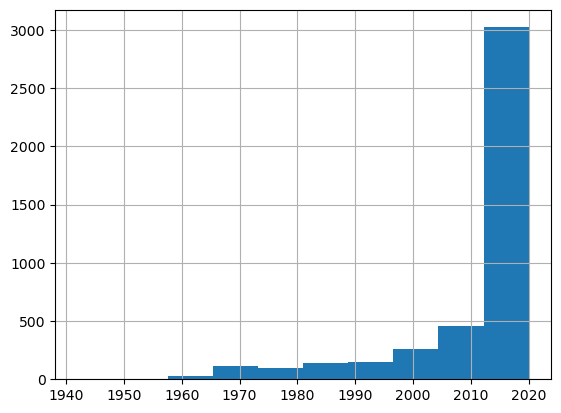

In [9]:
# checking year of hit songs
hit_songs = df[df["popularity"] > popularity_threshold]
hit_songs["year"].hist()

In [10]:
# creating binary target column 'hit'
df["hit"] = (df["popularity"] >= popularity_threshold).astype(int)
# getting hit value_counts
df["hit"].value_counts(normalize=True)

hit
0    0.970613
1    0.029387
Name: proportion, dtype: float64

In [11]:
df.isnull().sum().sort_values(ascending=False)

valence             0
liveness            0
tempo               0
speechiness         0
release_date        0
popularity          0
mode                0
loudness            0
key                 0
year                0
instrumentalness    0
explicit            0
energy              0
duration_ms         0
danceability        0
acousticness        0
hit                 0
dtype: int64

In [12]:
df["year"].describe()

count    170653.000000
mean       1976.787241
std          25.917853
min        1921.000000
25%        1956.000000
50%        1977.000000
75%        1999.000000
max        2020.000000
Name: year, dtype: float64

In [13]:
df["hit"].value_counts()
df["hit"].value_counts(normalize=True) * 100

hit
0    97.061288
1     2.938712
Name: proportion, dtype: float64

In [14]:
df["year"].value_counts().sort_index().head()
df["year"].value_counts().sort_index().tail()

year
2016    1797
2017    1992
2018    2103
2019    1949
2020    2030
Name: count, dtype: int64

<Axes: title={'center': 'Hit Rate Over Time'}, xlabel='year'>

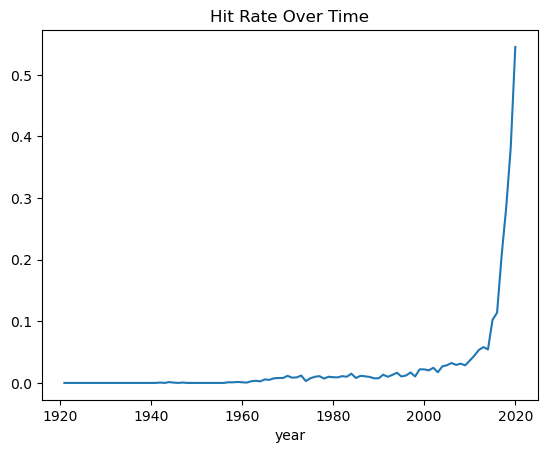

In [15]:
df.groupby("year")["hit"].mean().plot(
    title="Hit Rate Over Time"
)

In [16]:
# ============================
# Extra EDA 1: Quick overview
# ============================
print("Rows, Cols:", df.shape)
display(df.head(3))
display(df.sample(3, random_state=42))

print("\nColumn dtypes:")
display(df.dtypes.sort_values())

# memory usage
mem_mb = df.memory_usage(deep=True).sum() / (1024**2)
print(f"Approx memory usage: {mem_mb:.2f} MB")


Rows, Cols: (170653, 17)


,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,release_date,speechiness,tempo,hit
0,0.0594,1921,0.982,0.279,831667,0.211,0,0.878,10,0.665,-20.096,1,4,1921,0.0366,80.954,0
1,0.9630,1921,0.732,0.819,180533,0.341,0,0.000,7,0.160,-12.441,1,5,1921,0.4150,60.936,0
2,0.0394,1921,0.961,0.328,500062,0.166,0,0.913,3,0.101,-14.850,1,5,1921,0.0339,110.339,0


,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,release_date,speechiness,tempo,hit
116368,0.910,1977,0.500,0.894,273067,0.521,0,0.772,4,0.068,-7.048,1,34,1977,0.0847,126.805,0
161935,0.583,1976,0.930,0.585,182200,0.272,0,0.115,11,0.128,-16.693,0,26,1976,0.0802,90.104,0
135703,0.647,1994,0.157,0.878,179933,0.520,1,0.000,7,0.173,-12.609,1,38,1994-06-07,0.4030,90.744,0



Column dtypes:


hit                   int32
popularity            int64
mode                  int64
explicit              int64
key                   int64
year                  int64
duration_ms           int64
energy              float64
danceability        float64
instrumentalness    float64
tempo               float64
liveness            float64
loudness            float64
acousticness        float64
speechiness         float64
valence             float64
release_date         object
dtype: object

Approx memory usage: 29.49 MB


In [17]:
# =====================================
# Extra EDA 2: Duplicates / uniqueness
# =====================================
dup_rows = df.duplicated().sum()
print("Duplicate rows:", dup_rows, f"({dup_rows/len(df)*100:.2f}%)")

# Column-level uniqueness (helps spot IDs/categoricals)
uniq = df.nunique(dropna=False).sort_values(ascending=False)
display(uniq.to_frame("n_unique").head(15))

# If you have 'name'/'artists' dropped, try a near-duplicate check on remaining numeric cols
num_cols = df.select_dtypes(include="number").columns
if len(num_cols) > 0:
    dup_num = df[num_cols].duplicated().sum()
    print("Duplicate rows considering only numeric columns:", dup_num)


Duplicate rows: 710 (0.42%)


,n_unique
tempo,84694
duration_ms,51755
loudness,25410
release_date,11244
instrumentalness,5401
acousticness,4689
energy,2332
liveness,1740
valence,1733
speechiness,1626


Duplicate rows considering only numeric columns: 750


In [18]:
# =========================================
# Extra EDA 3: Missingness + target sanity
# =========================================
missing = df.isna().mean().sort_values(ascending=False)
display((missing * 100).to_frame("% missing").head(15))

print("\nHit distribution:")
display(df["hit"].value_counts().to_frame("count"))
display((df["hit"].value_counts(normalize=True) * 100).to_frame("%"))

# Hit rate by decade (temporal structure)
if "year" in df.columns:
    decade = (df["year"] // 10) * 10
    hit_by_decade = df.groupby(decade)["hit"].mean().sort_index()
    display(hit_by_decade.to_frame("hit_rate"))


,% missing
valence,0.0
liveness,0.0
tempo,0.0
speechiness,0.0
release_date,0.0
popularity,0.0
mode,0.0
loudness,0.0
key,0.0
year,0.0



Hit distribution:


,count
hit,
0,165638
1,5015


,%
hit,
0,97.061288
1,2.938712


,hit_rate
year,
1920,0.000000
1930,0.000000
1940,0.000260
1950,0.000353
1960,0.004502
1970,0.008950
1980,0.010176
1990,0.013215
2000,0.026112


Key numeric columns found: ['popularity', 'duration_ms', 'tempo', 'loudness', 'energy', 'danceability', 'valence', 'acousticness', 'instrumentalness', 'liveness', 'speechiness']


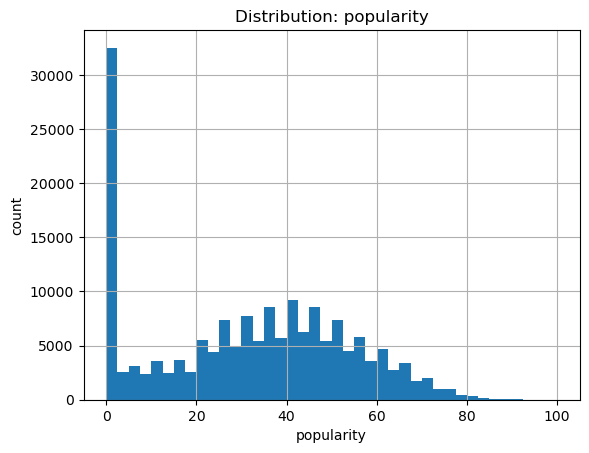

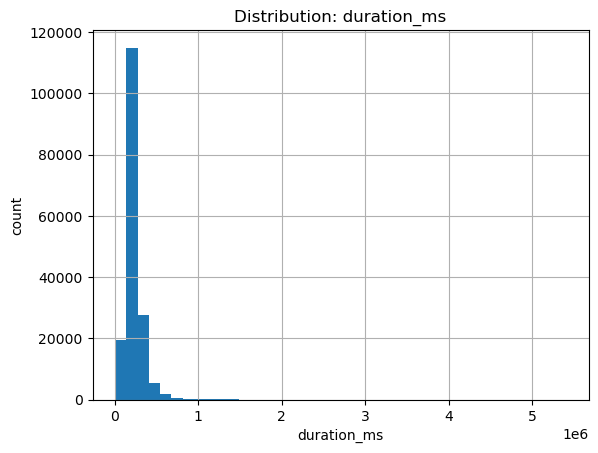

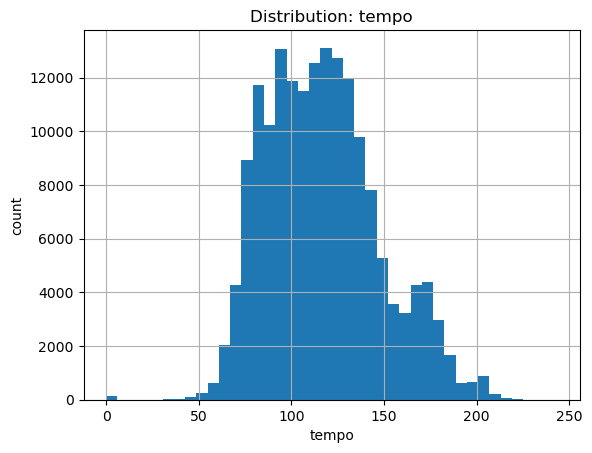

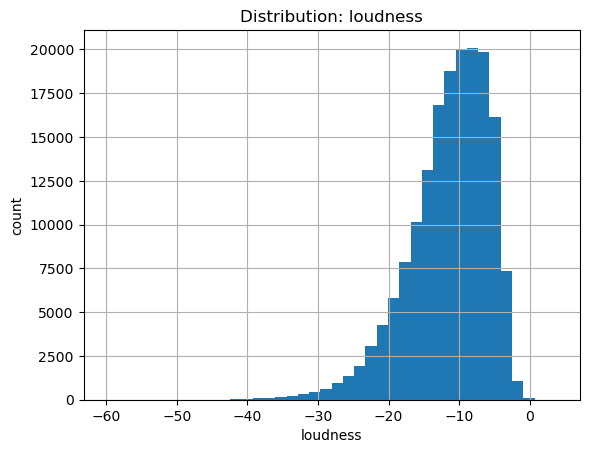

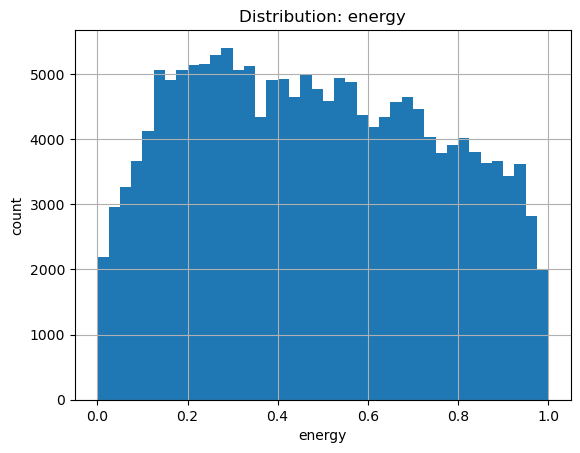

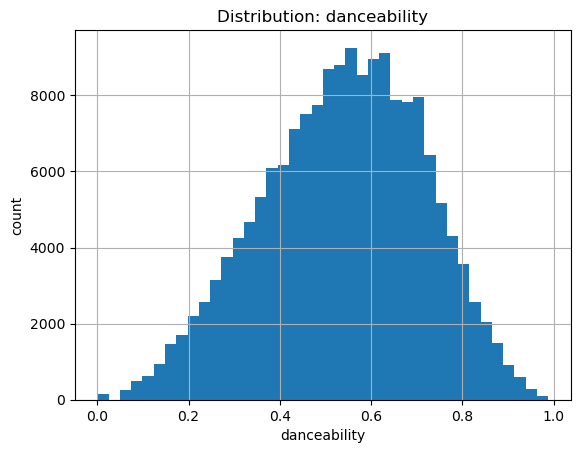

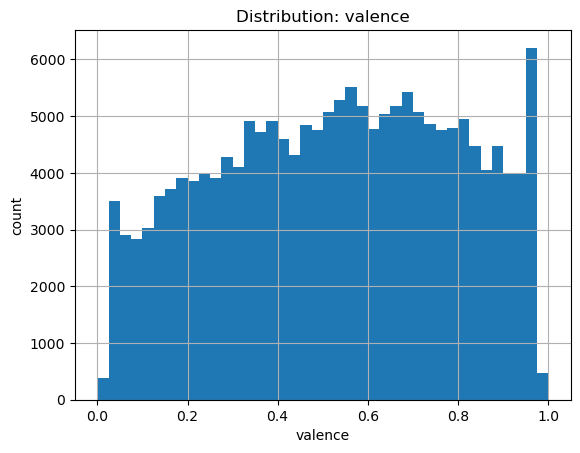

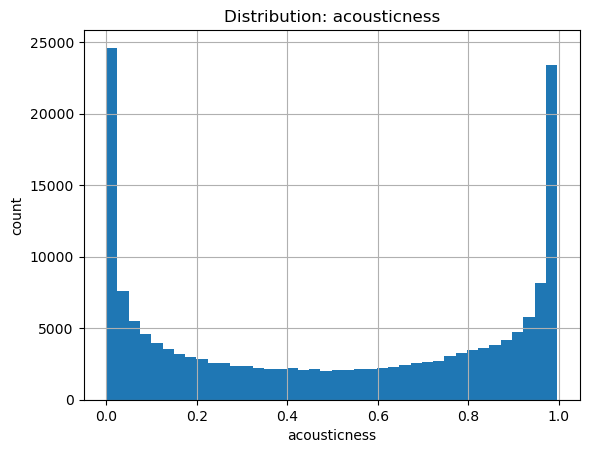

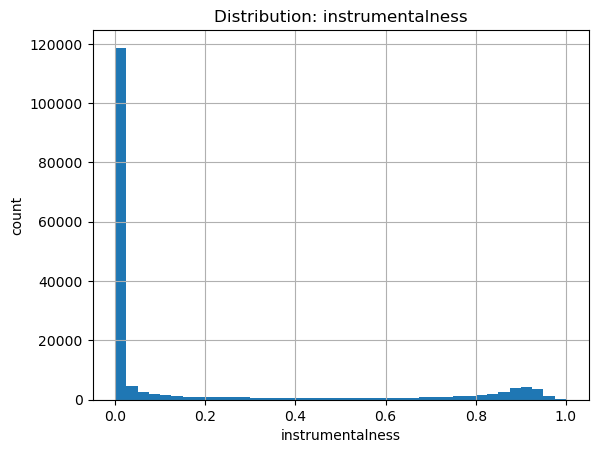

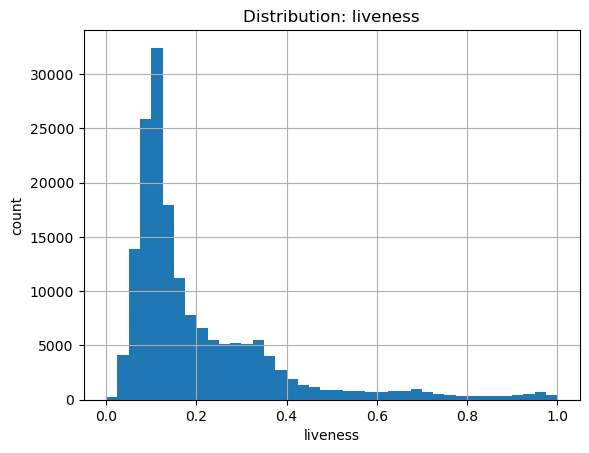

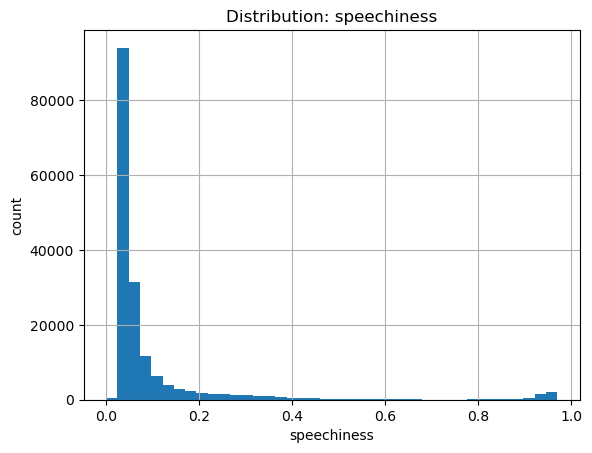

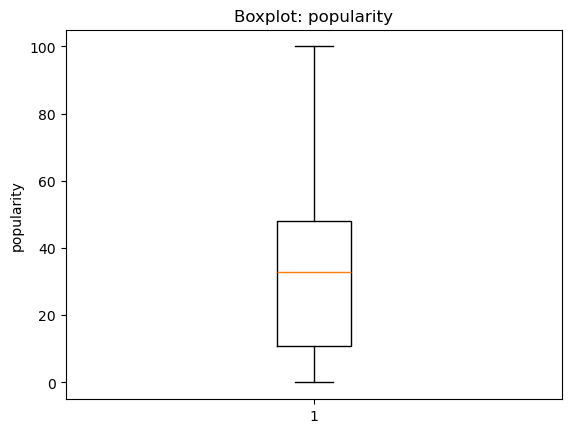

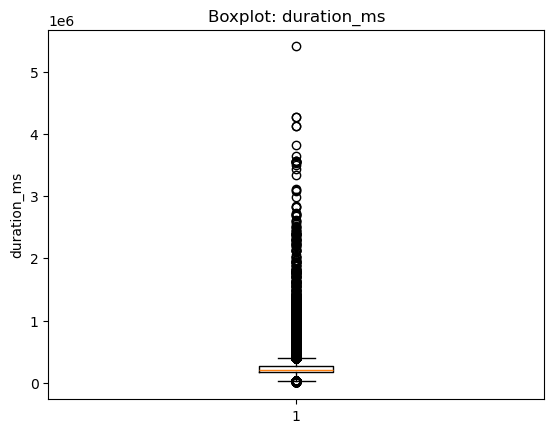

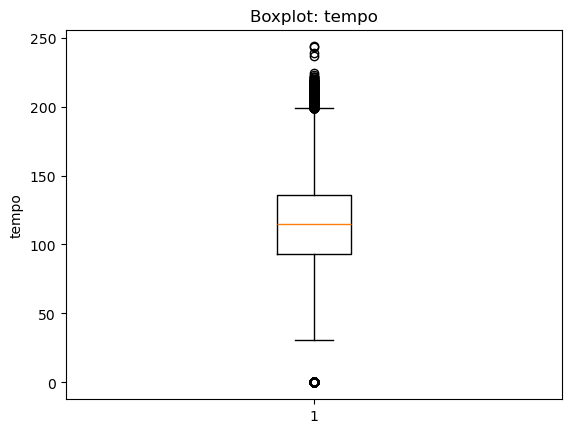

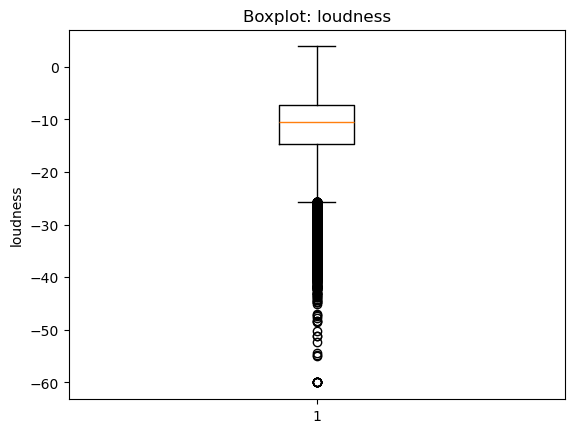

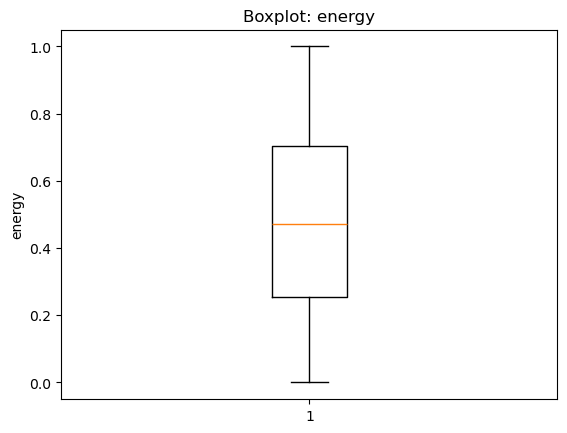

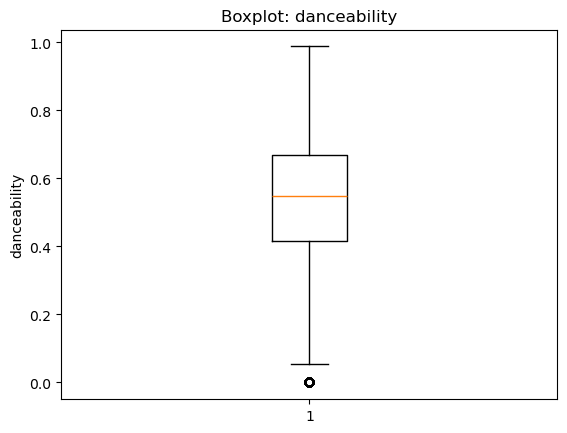

In [19]:
# ==================================================
# Extra EDA 4: Distributions of key numeric features
# ==================================================
import matplotlib.pyplot as plt

key_candidates = [
    "popularity","duration_ms","tempo","loudness","energy","danceability",
    "valence","acousticness","instrumentalness","liveness","speechiness"
]
key_cols = [c for c in key_candidates if c in df.columns]

print("Key numeric columns found:", key_cols)

for c in key_cols:
    plt.figure()
    df[c].hist(bins=40)
    plt.title(f"Distribution: {c}")
    plt.xlabel(c)
    plt.ylabel("count")
    plt.show()

# Boxplot view for outliers (limited to first 6 columns to keep it readable)
for c in key_cols[:6]:
    plt.figure()
    plt.boxplot(df[c].dropna(), vert=True)
    plt.title(f"Boxplot: {c}")
    plt.ylabel(c)
    plt.show()


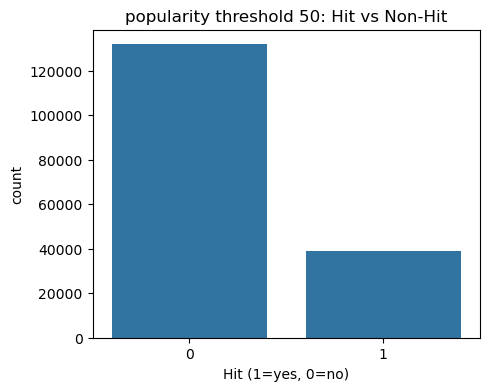

In [20]:
# side by side countplot for hit vs non-hit based on popularity threshold (80, 70, 60, and 50) on a single plot


plt.figure(figsize=(5,4))
sns.countplot(x=(df['popularity'] >= 50).astype(int))
plt.title("popularity threshold 50: Hit vs Non-Hit")
plt.xlabel("Hit (1=yes, 0=no)")
plt.show()

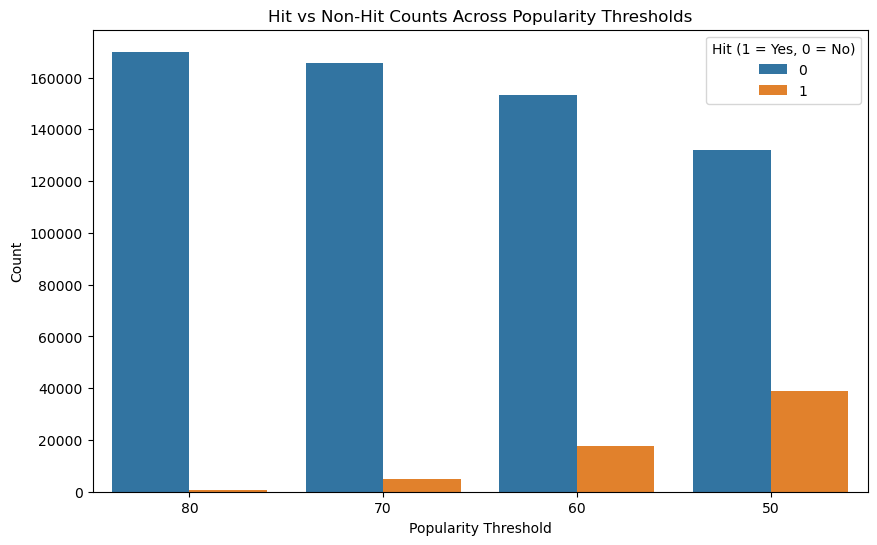

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create hit columns for each threshold
thresholds = [80, 70, 60, 50]

for t in thresholds:
    df[f"hit_{t}"] = (df["popularity"] >= t).astype(int)

# Reshape dataframe for plotting
plot_df = df[[f"hit_{t}" for t in thresholds]].melt(
    var_name="Threshold",
    value_name="Hit"
)

# Clean threshold labels
plot_df["Threshold"] = plot_df["Threshold"].str.replace("hit_", "")

# Plot
plt.figure(figsize=(10,6))
sns.countplot(data=plot_df, x="Threshold", hue="Hit")

plt.title("Hit vs Non-Hit Counts Across Popularity Thresholds")
plt.xlabel("Popularity Threshold")
plt.ylabel("Count")
plt.legend(title="Hit (1 = Yes, 0 = No)")
plt.show()

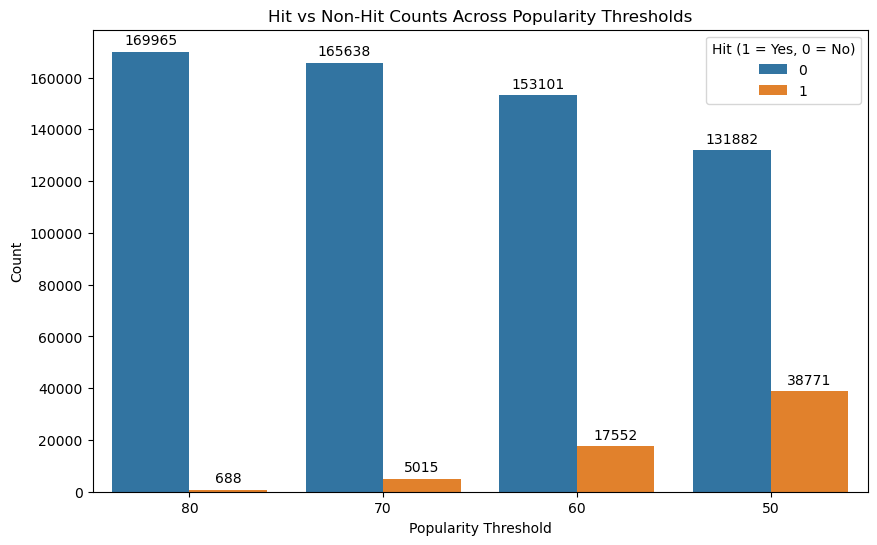

In [32]:
plt.figure(figsize=(10,6))
ax = sns.countplot(data=plot_df, x="Threshold", hue="Hit")

plt.title("Hit vs Non-Hit Counts Across Popularity Thresholds")
plt.xlabel("Popularity Threshold")
plt.ylabel("Count")
plt.legend(title="Hit (1 = Yes, 0 = No)")

# 🔹 Add count labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.show()

,corr_with_hit
hit_70,1.000000
hit,1.000000
hit_60,0.513903
hit_80,0.365644
popularity,0.345088
hit_50,0.320918
year,0.231244
explicit,0.150989
loudness,0.139489
danceability,0.106016


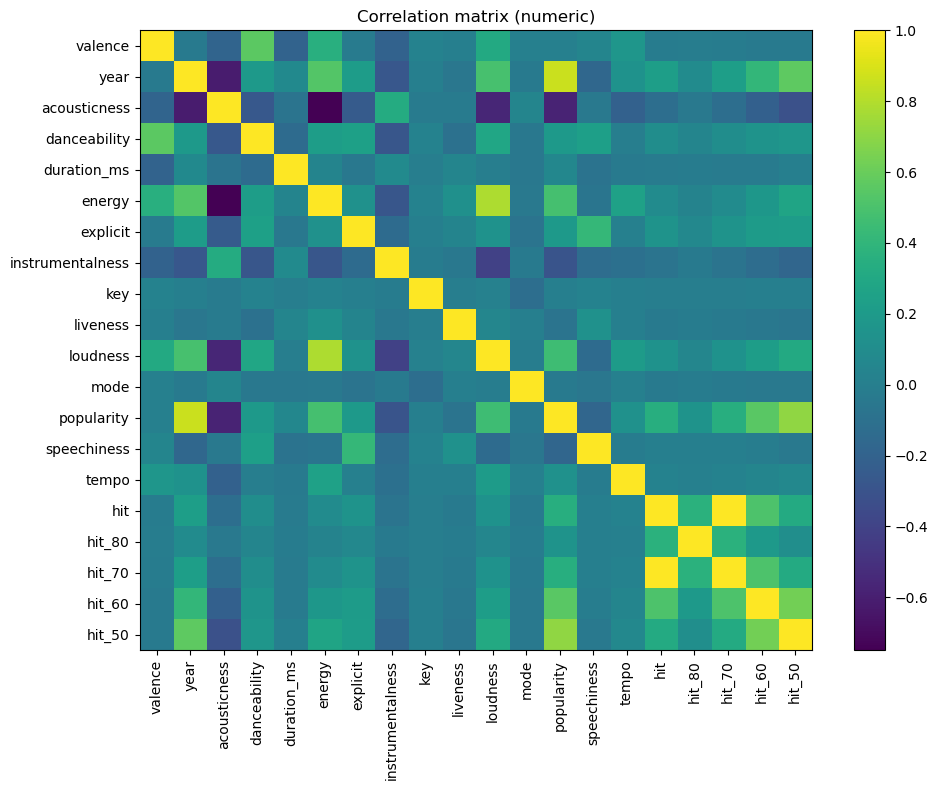

In [22]:
# =========================================
# Extra EDA 5: Correlations (numeric + hit)
# =========================================
import matplotlib.pyplot as plt
import numpy as np

num_df = df.select_dtypes(include="number").copy()

# Correlation with hit 
if "hit" in num_df.columns:
    corr_hit = num_df.corr(numeric_only=True)["hit"].dropna().sort_values(ascending=False)
    display(corr_hit.to_frame("corr_with_hit"))

# Full correlation heatmap 
corr = num_df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
plt.imshow(corr.values, aspect="auto")
plt.title("Correlation matrix (numeric)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.tight_layout()
plt.show()


,mean_pop,hit_rate,n
year,,,
1921,0.653333,0.0,150
1922,0.140845,0.0,71
1923,5.389189,0.0,185
1924,0.661017,0.0,236
1925,2.604317,0.0,278


,mean_pop,hit_rate,n
year,,,
2016,59.647190,0.114079,1797
2017,63.263554,0.206827,1992
2018,63.296243,0.284356,2103
2019,65.256542,0.382247,1949
2020,64.301970,0.545320,2030


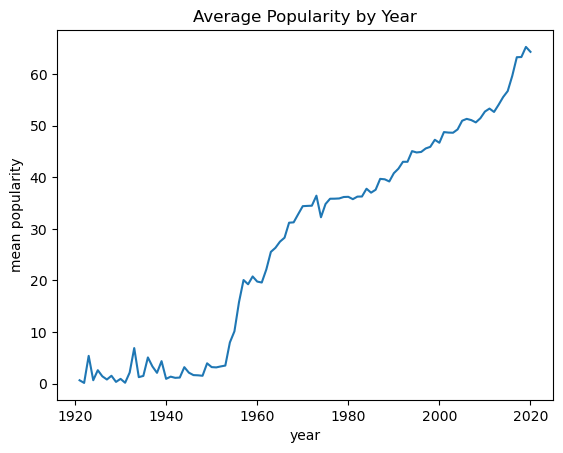

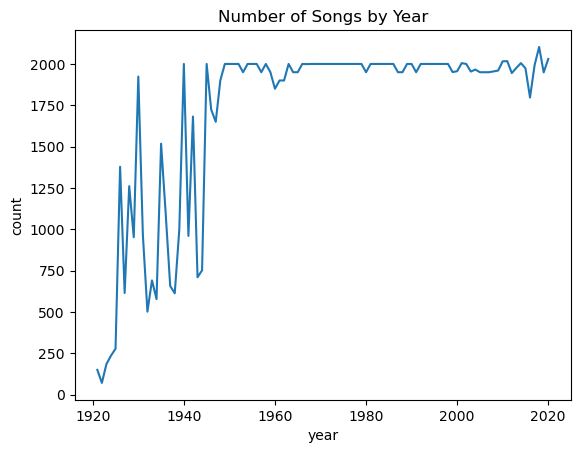

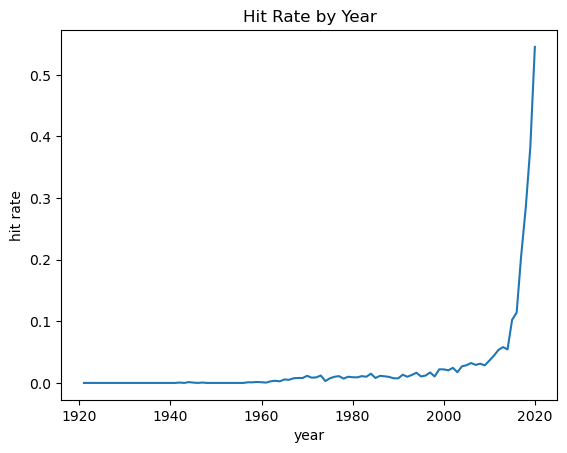

In [23]:
# ==========================================
# Extra EDA 6: Time trends (year vs features)
# ==========================================
import matplotlib.pyplot as plt

if "year" in df.columns:
    yearly = df.groupby("year").agg(
        mean_pop=("popularity","mean"),
        hit_rate=("hit","mean"),
        n=("hit","size")
    ).sort_index()

    display(yearly.head())
    display(yearly.tail())

    plt.figure()
    yearly["mean_pop"].plot(title="Average Popularity by Year")
    plt.ylabel("mean popularity")
    plt.show()

    plt.figure()
    yearly["n"].plot(title="Number of Songs by Year")
    plt.ylabel("count")
    plt.show()

    plt.figure()
    yearly["hit_rate"].plot(title="Hit Rate by Year")
    plt.ylabel("hit rate")
    plt.show()
else:
    print("No 'year' column found.")


In [24]:
# correlation with popularity and other features
corr_popularity = df.corr(numeric_only=True)["popularity"].dropna().sort_values(ascending=False)
display(corr_popularity.to_frame("corr_with_popularity"))

,corr_with_popularity
popularity,1.000000
year,0.862442
hit_50,0.708648
hit_60,0.551416
energy,0.485005
loudness,0.457051
hit,0.345088
hit_70,0.345088
danceability,0.199606
explicit,0.191543


In [25]:
# ============================
# Modeling setup (pipelines)
# ============================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report
)

RANDOM_STATE = 42

# (Safe to run even if df already exists.)
try:
    df
except NameError:
    from pathlib import Path
    candidate_paths = [
        Path("data/data.csv"),
        Path("./data.csv"),
        Path("/mnt/data/data.csv"),
    ]
    for p in candidate_paths:
        if p.exists():
            DATA_PATH = p
            break
    else:
        raise FileNotFoundError(
            "Couldn't find data.csv. Put it in ./data/data.csv or update candidate_paths in this cell."
        )
    df = pd.read_csv(DATA_PATH)

# Sanity: make sure target exists
if "hit" not in df.columns:
    # You can edit threshold here if needed
    popularity_threshold = 70
    df["hit"] = (df["popularity"] >= popularity_threshold).astype(int)

df.shape, df["hit"].value_counts(normalize=True)


((170653, 21),
 hit
 0    0.970613
 1    0.029387
 Name: proportion, dtype: float64)

In [26]:
# ============================
# Feature / target definitions
# ============================

TARGET_COL = "hit"

# Drop columns we don't want to leak with, or that aren't usable as features
DROP_COLS = [
    "popularity",          # popularity is what we thresholded to make 'hit'
    "release_date",        # if present; year is enough for time control
]

# Most of these are numeric audio features in the dataset.
# Treat 'key' and 'mode' as categorical-ish (key: 0-11, mode: 0/1)
NUMERIC_FEATURES = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence",
    "tempo", "duration_ms"
]
CATEGORICAL_FEATURES = ["key", "mode"]

# Optional: include year as a control feature in some runs
YEAR_FEATURE = ["year"]

def make_X_y(df: pd.DataFrame, include_year: bool) -> tuple[pd.DataFrame, pd.Series]:
    use_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES + (YEAR_FEATURE if include_year else [])
    existing = [c for c in use_cols if c in df.columns]
    X = df[existing].copy()
    y = df[TARGET_COL].astype(int).copy()
    return X, y

def make_preprocessor(include_year: bool) -> ColumnTransformer:
    numeric_cols = [c for c in NUMERIC_FEATURES + (YEAR_FEATURE if include_year else []) if c in df.columns]
    categorical_cols = [c for c in CATEGORICAL_FEATURES if c in df.columns]

    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_cols),
            ("cat", cat_pipe, categorical_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )


In [27]:
# ============================
# Split helpers (random / temporal / era)
# ============================

def random_split(df: pd.DataFrame, test_size: float = 0.2, include_year: bool = True):
    X, y = make_X_y(df, include_year=include_year)
    return train_test_split(
        X, y,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=y
    )

def temporal_split(df: pd.DataFrame, split_year: int, include_year: bool = True):
    """Train on years < split_year, test on years >= split_year."""
    if "year" not in df.columns:
        raise ValueError("temporal_split requires a 'year' column in df.")

    train_df = df[df["year"] < split_year].copy()
    test_df  = df[df["year"] >= split_year].copy()

    X_train, y_train = make_X_y(train_df, include_year=include_year)
    X_test, y_test   = make_X_y(test_df, include_year=include_year)
    return X_train, X_test, y_train, y_test

def era_split(df: pd.DataFrame, train_years: tuple[int,int], test_years: tuple[int,int], include_year: bool = True):
    """Example: train_years=(1980, 1990) means 1980-1989 inclusive."""
    if "year" not in df.columns:
        raise ValueError("era_split requires a 'year' column in df.")

    tr0, tr1 = train_years
    te0, te1 = test_years
    train_df = df[(df["year"] >= tr0) & (df["year"] <= tr1)].copy()
    test_df  = df[(df["year"] >= te0) & (df["year"] <= te1)].copy()

    X_train, y_train = make_X_y(train_df, include_year=include_year)
    X_test, y_test   = make_X_y(test_df, include_year=include_year)
    return X_train, X_test, y_train, y_test

def print_split_stats(y_train, y_test, label=""):
    def pct(y): return float(np.mean(y))*100
    print(label)
    print(f"  train n={len(y_train):,}  hit%={pct(y_train):.2f}")
    print(f"  test  n={len(y_test):,}  hit%={pct(y_test):.2f}")


In [28]:
# ============================
# Evaluation helper
# ============================

def evaluate_binary_classifier(model, X_train, y_train, X_test, y_test, *, name="model"):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # Some models don't expose predict_proba; fall back to decision_function
    y_score = None
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)
        # map to [0,1] monotonically (for AUC/AP usage)
        y_score = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }
    if y_score is not None:
        metrics["roc_auc"] = roc_auc_score(y_test, y_score)
        metrics["avg_precision"] = average_precision_score(y_test, y_score)

    print(f"\n===== {name} =====")
    for k,v in metrics.items():
        print(f"{k:>14}: {v:.4f}")
    print("\nConfusion matrix [ [TN FP], [FN TP] ]:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, digits=4, zero_division=0))

    return metrics


In [29]:
# ============================
# Model pipelines (edit these)
# ============================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

def make_model_pipelines(include_year: bool = True):
    pre = make_preprocessor(include_year=include_year)

    # Baseline 1: Logistic Regression (good baseline for imbalanced data with class_weight)
    logreg = Pipeline(steps=[
        ("preprocess", pre),
        ("clf", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=None
        ))
    ])

    # Baseline 2: Random Forest (handles non-linearities; can struggle with heavy imbalance)
    rf = Pipeline(steps=[
        ("preprocess", pre),
        ("clf", RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=1,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    # Baseline 3: Histogram Gradient Boosting (fast tree boosting; try tuning max_depth/learning_rate)
    hgb = Pipeline(steps=[
        ("preprocess", pre),
        ("clf", HistGradientBoostingClassifier(
            max_depth=6,
            learning_rate=0.08,
            max_iter=250,
            random_state=RANDOM_STATE
        ))
    ])

    # MLP1-like: Standardize numeric + onehot categorical, then MLP
    # NOTE: MLP can be sensitive; start small and tune hidden_layer_sizes / alpha / learning_rate_init.
    mlp1 = Pipeline(steps=[
        ("preprocess", pre),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            solver="adam",
            alpha=1e-4,                # L2 regularization
            learning_rate_init=1e-3,
            max_iter=50,              # raise (100-300) after you verify it runs
            early_stopping=True,
            validation_fraction=0.1,
            random_state=RANDOM_STATE
        ))
    ])

    return {
        "LogReg_balanced": logreg,
        "RandomForest_balanced": rf,
        "HistGB": hgb,
        "MLP1": mlp1,
    }


In [30]:

# Random split
# X_train, X_test, y_train, y_test = random_split(df, test_size=0.2, include_year=True)
# print_split_stats(y_train, y_test, label="Random split (include_year=True)")

# Temporal split
X_train, X_test, y_train, y_test = temporal_split(df, split_year=2015, include_year=True)
print_split_stats(y_train, y_test, label="Temporal split: train<2015, test>=2015")

# Era split 
# X_train, X_test, y_train, y_test = era_split(df, train_years=(1990, 1999), test_years=(2010, 2019), include_year=True)
# print_split_stats(y_train, y_test, label="Era split: train 90s, test 2010s")

pipelines = make_model_pipelines(include_year=True)

results = {}
for name, pipe in pipelines.items():
    results[name] = evaluate_binary_classifier(pipe, X_train, y_train, X_test, y_test, name=name)

pd.DataFrame(results).T.sort_values("f1", ascending=False)


Temporal split: train<2015, test>=2015
  train n=158,808  hit%=1.10
  test  n=11,845  hit%=27.60

===== LogReg_balanced =====
      accuracy: 0.3336
     precision: 0.2893
        recall: 0.9709
            f1: 0.4458
       roc_auc: 0.6173
 avg_precision: 0.3603

Confusion matrix [ [TN FP], [FN TP] ]:
[[ 778 7798]
 [  95 3174]]

Classification report:
              precision    recall  f1-score   support

           0     0.8912    0.0907    0.1647      8576
           1     0.2893    0.9709    0.4458      3269

    accuracy                         0.3336     11845
   macro avg     0.5902    0.5308    0.3052     11845
weighted avg     0.7251    0.3336    0.2422     11845


===== RandomForest_balanced =====
      accuracy: 0.7240
     precision: 0.0000
        recall: 0.0000
            f1: 0.0000
       roc_auc: 0.5728
 avg_precision: 0.3206

Confusion matrix [ [TN FP], [FN TP] ]:
[[8576    0]
 [3269    0]]

Classification report:
              precision    recall  f1-score   support


c:\Users\longt\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\longt\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\longt\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\longt\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\longt\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro


===== HistGB =====
      accuracy: 0.7240
     precision: 0.0000
        recall: 0.0000
            f1: 0.0000
       roc_auc: 0.5818
 avg_precision: 0.3280

Confusion matrix [ [TN FP], [FN TP] ]:
[[8576    0]
 [3269    0]]

Classification report:
              precision    recall  f1-score   support

           0     0.7240    1.0000    0.8399      8576
           1     0.0000    0.0000    0.0000      3269

    accuracy                         0.7240     11845
   macro avg     0.3620    0.5000    0.4200     11845
weighted avg     0.5242    0.7240    0.6081     11845


===== MLP1 =====
      accuracy: 0.7240
     precision: 0.0000
        recall: 0.0000
            f1: 0.0000
       roc_auc: 0.6108
 avg_precision: 0.3537

Confusion matrix [ [TN FP], [FN TP] ]:
[[8576    0]
 [3269    0]]

Classification report:
              precision    recall  f1-score   support

           0     0.7240    1.0000    0.8399      8576
           1     0.0000    0.0000    0.0000      3269

    accuracy 

,accuracy,precision,recall,f1,roc_auc,avg_precision
LogReg_balanced,0.333643,0.289282,0.970939,0.445755,0.617348,0.360309
RandomForest_balanced,0.724019,0.000000,0.000000,0.000000,0.572832,0.320615
HistGB,0.724019,0.000000,0.000000,0.000000,0.581831,0.328007
MLP1,0.724019,0.000000,0.000000,0.000000,0.610803,0.353691


In [31]:
# ============================
# Compare: with year vs without year (same split)
# ============================

split_year = 2015

# WITH year
X_train_y, X_test_y, y_train_y, y_test_y = temporal_split(df, split_year=split_year, include_year=True)
print_split_stats(y_train_y, y_test_y, label=f"Temporal split (WITH year feature): train<{split_year}, test>={split_year}")

pipelines_y = make_model_pipelines(include_year=True)
res_with_year = {name: evaluate_binary_classifier(pipe, X_train_y, y_train_y, X_test_y, y_test_y, name=f"{name} (with year)")
                 for name, pipe in pipelines_y.items()}

# WITHOUT year
X_train_n, X_test_n, y_train_n, y_test_n = temporal_split(df, split_year=split_year, include_year=False)
print_split_stats(y_train_n, y_test_n, label=f"Temporal split (NO year feature): train<{split_year}, test>={split_year}")

pipelines_n = make_model_pipelines(include_year=False)
res_no_year = {name: evaluate_binary_classifier(pipe, X_train_n, y_train_n, X_test_n, y_test_n, name=f"{name} (no year)")
               for name, pipe in pipelines_n.items()}

comparison = (
    pd.DataFrame(res_with_year).T.add_prefix("with_year__")
      .join(pd.DataFrame(res_no_year).T.add_prefix("no_year__"))
)
comparison


Temporal split (WITH year feature): train<2015, test>=2015
  train n=158,808  hit%=1.10
  test  n=11,845  hit%=27.60

===== LogReg_balanced (with year) =====
      accuracy: 0.3336
     precision: 0.2893
        recall: 0.9709
            f1: 0.4458
       roc_auc: 0.6173
 avg_precision: 0.3603

Confusion matrix [ [TN FP], [FN TP] ]:
[[ 778 7798]
 [  95 3174]]

Classification report:
              precision    recall  f1-score   support

           0     0.8912    0.0907    0.1647      8576
           1     0.2893    0.9709    0.4458      3269

    accuracy                         0.3336     11845
   macro avg     0.5902    0.5308    0.3052     11845
weighted avg     0.7251    0.3336    0.2422     11845


===== RandomForest_balanced (with year) =====
      accuracy: 0.7240
     precision: 0.0000
        recall: 0.0000
            f1: 0.0000
       roc_auc: 0.5728
 avg_precision: 0.3206

Confusion matrix [ [TN FP], [FN TP] ]:
[[8576    0]
 [3269    0]]

Classification report:
          

c:\Users\longt\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


,with_year__accuracy,with_year__precision,with_year__recall,with_year__f1,with_year__roc_auc,with_year__avg_precision,no_year__accuracy,no_year__precision,no_year__recall,no_year__f1,no_year__roc_auc,no_year__avg_precision
LogReg_balanced,0.333643,0.289282,0.970939,0.445755,0.617348,0.360309,0.408780,0.301678,0.868767,0.447844,0.589439,0.326410
RandomForest_balanced,0.724019,0.000000,0.000000,0.000000,0.572832,0.320615,0.723850,0.000000,0.000000,0.000000,0.563041,0.317786
HistGB,0.724019,0.000000,0.000000,0.000000,0.581831,0.328007,0.724019,0.000000,0.000000,0.000000,0.577642,0.333197
MLP1,0.724019,0.000000,0.000000,0.000000,0.610803,0.353691,0.724019,0.000000,0.000000,0.000000,0.593558,0.341275
